# Classificação de Pagamento de Empréstimos

O notebook compara três modelos para classificação binária de pagamento de empréstimos:

* **Logistic Regression**;
* **K-Nearest Neighbors Classifier**;
* **Gradient Boosting Classifier**.

O pré-processamento inclui **One-Hot Encoding** para variáveis categóricas, **StandardScaler** para atributos numéricos, transformações `log1p` em variáveis assimétricas e criação de indicadores binários derivados dos dados originais.

Os dados são divididos em:

* **60% — treino**;
* **10% — validação**;
* **10% — calibração**;
* **20% — teste**.

Após o treinamento, as probabilidades dos modelos são calibradas por **Platt Scaling**, utilizando exclusivamente o conjunto de calibração. A qualidade das probabilidades é analisada por **curvas de calibração, Brier Score e Log Loss**.

Os limiares de classificação são escolhidos no conjunto de validação por **minimização de custo assimétrico**, atribuindo ao falso positivo um custo dez vezes maior que ao falso negativo.

A avaliação final utiliza **ROC/AUC, matriz de confusão e classification report**, comparando os modelos após calibração e ajuste de seus respectivos limiares.


## Carregando os dados

In [1]:
import pandas as pd

cols = ['ESCT', 'NDEP', 'RENDA', 'TIPOR', 'VBEM', 'NPARC', 'VPARC', 'TEL', 'IDADE', 'RESMS', 'ENTRADA', 'CLASSE']

df_train = pd.read_csv('../data/credtrain.txt', sep='\t', header=None, names=cols)
df_test  = pd.read_csv('../data/credtest.txt',  sep='\t', header=None, names=cols)

print(f"Treino: {df_train.shape} | Teste: {df_test.shape}")
df_train.head()

Treino: (1500, 12) | Teste: (577, 12)


,ESCT,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,CLASSE
0,1,0,360,0,313,9,52,0,25,48,0,1
1,0,0,350,1,468,10,65,0,33,6,0,1
2,0,0,1100,0,829,9,125,0,56,48,0,1
3,0,0,3000,0,552,12,76,1,31,60,0,1
4,1,0,1000,0,809,12,111,0,24,7,0,1


##  EDA
Análise Exploratória para entender a disposição das features enquano variáveis contínuas/categóricas e investigar possíveis estratégias de pré processamento antes de treinar os modelos


In [2]:
print("Dados de treino:", df_train.shape)
print("Dados de teste:", df_test.shape)

print("\nColunas dos datasets:", df_train.columns.tolist())

print("\nTipos de dados do dataset de treino:\n", df_train.dtypes)


Dados de treino: (1500, 12)
Dados de teste: (577, 12)

Colunas dos datasets: ['ESCT', 'NDEP', 'RENDA', 'TIPOR', 'VBEM', 'NPARC', 'VPARC', 'TEL', 'IDADE', 'RESMS', 'ENTRADA', 'CLASSE']

Tipos de dados do dataset de treino:
 ESCT       int64
NDEP       int64
RENDA      int64
TIPOR      int64
VBEM       int64
NPARC      int64
VPARC      int64
TEL        int64
IDADE      int64
RESMS      int64
ENTRADA    int64
CLASSE     int64
dtype: object


In [3]:
print("\nMedidas de tendência central e dispersão dos dados de treino:" )
print(df_train.describe().round(1).T)


Medidas de tendência central e dispersão dos dados de treino:
          count   mean    std    min    25%    50%     75%     max
ESCT     1500.0    0.5    0.7    0.0    0.0    0.0     1.0     3.0
NDEP     1500.0    0.1    0.6    0.0    0.0    0.0     0.0     7.0
RENDA    1500.0  984.5  905.5  300.0  467.5  650.0  1200.0  8000.0
TIPOR    1500.0    0.4    0.5    0.0    0.0    0.0     1.0     1.0
VBEM     1500.0  562.0  265.7  300.0  410.0  490.0   618.0  4000.0
NPARC    1500.0    8.4    3.6    1.0    6.0   10.0    10.0    24.0
VPARC    1500.0  102.2   63.0   50.0   66.0   83.0   118.0   711.0
TEL      1500.0    0.1    0.3    0.0    0.0    0.0     0.0     1.0
IDADE    1500.0   41.2   13.2   19.0   31.0   39.0    52.0    70.0
RESMS    1500.0   31.5   52.7    0.0    6.0    6.0    48.0   420.0
ENTRADA  1500.0   32.3   94.3    0.0    0.0    0.0     0.0  1300.0
CLASSE   1500.0    0.5    0.5    0.0    0.0    0.0     1.0     1.0


Regressão Logística e KNN são algoritmos sensíveis a dados em escalas muito diferentes. Por exemplo, a variável (`RENDA`) tem valores na casa dos milhares, enquanto (`IDADE`) tem valores na casa das dezenas. Se não normalizarmos ou padronizarmos os dados, o modelo pode dar mais peso para a variável (`RENDA`) do que para (`IDADE`), o que pode levar a um desempenho ruim do modelo. Vamos usar o StandartScale pra diminuir a diferença de escalas e o log1p pra corrigir assimetria em variáveis que precisem

In [4]:
print("Valores únicos por coluna no dataset de treino:\n")
for col in df_train.columns:
    unique_values = df_train[col].unique()
    print(f"{col}: {len(unique_values)} valores únicos")

Valores únicos por coluna no dataset de treino:

ESCT: 4 valores únicos
NDEP: 8 valores únicos
RENDA: 516 valores únicos
TIPOR: 2 valores únicos
VBEM: 515 valores únicos
NPARC: 16 valores únicos
VPARC: 216 valores únicos
TEL: 2 valores únicos
IDADE: 52 valores únicos
RESMS: 54 valores únicos
ENTRADA: 127 valores únicos
CLASSE: 2 valores únicos


 Feature alvo (CLASSE) não apresenta desbalanceamento. Temos que usar encoding na feature ESCT (Estado Civil). Como é uma feature de 4 clases, numérica e sem ordem, vou usar one hot encoding

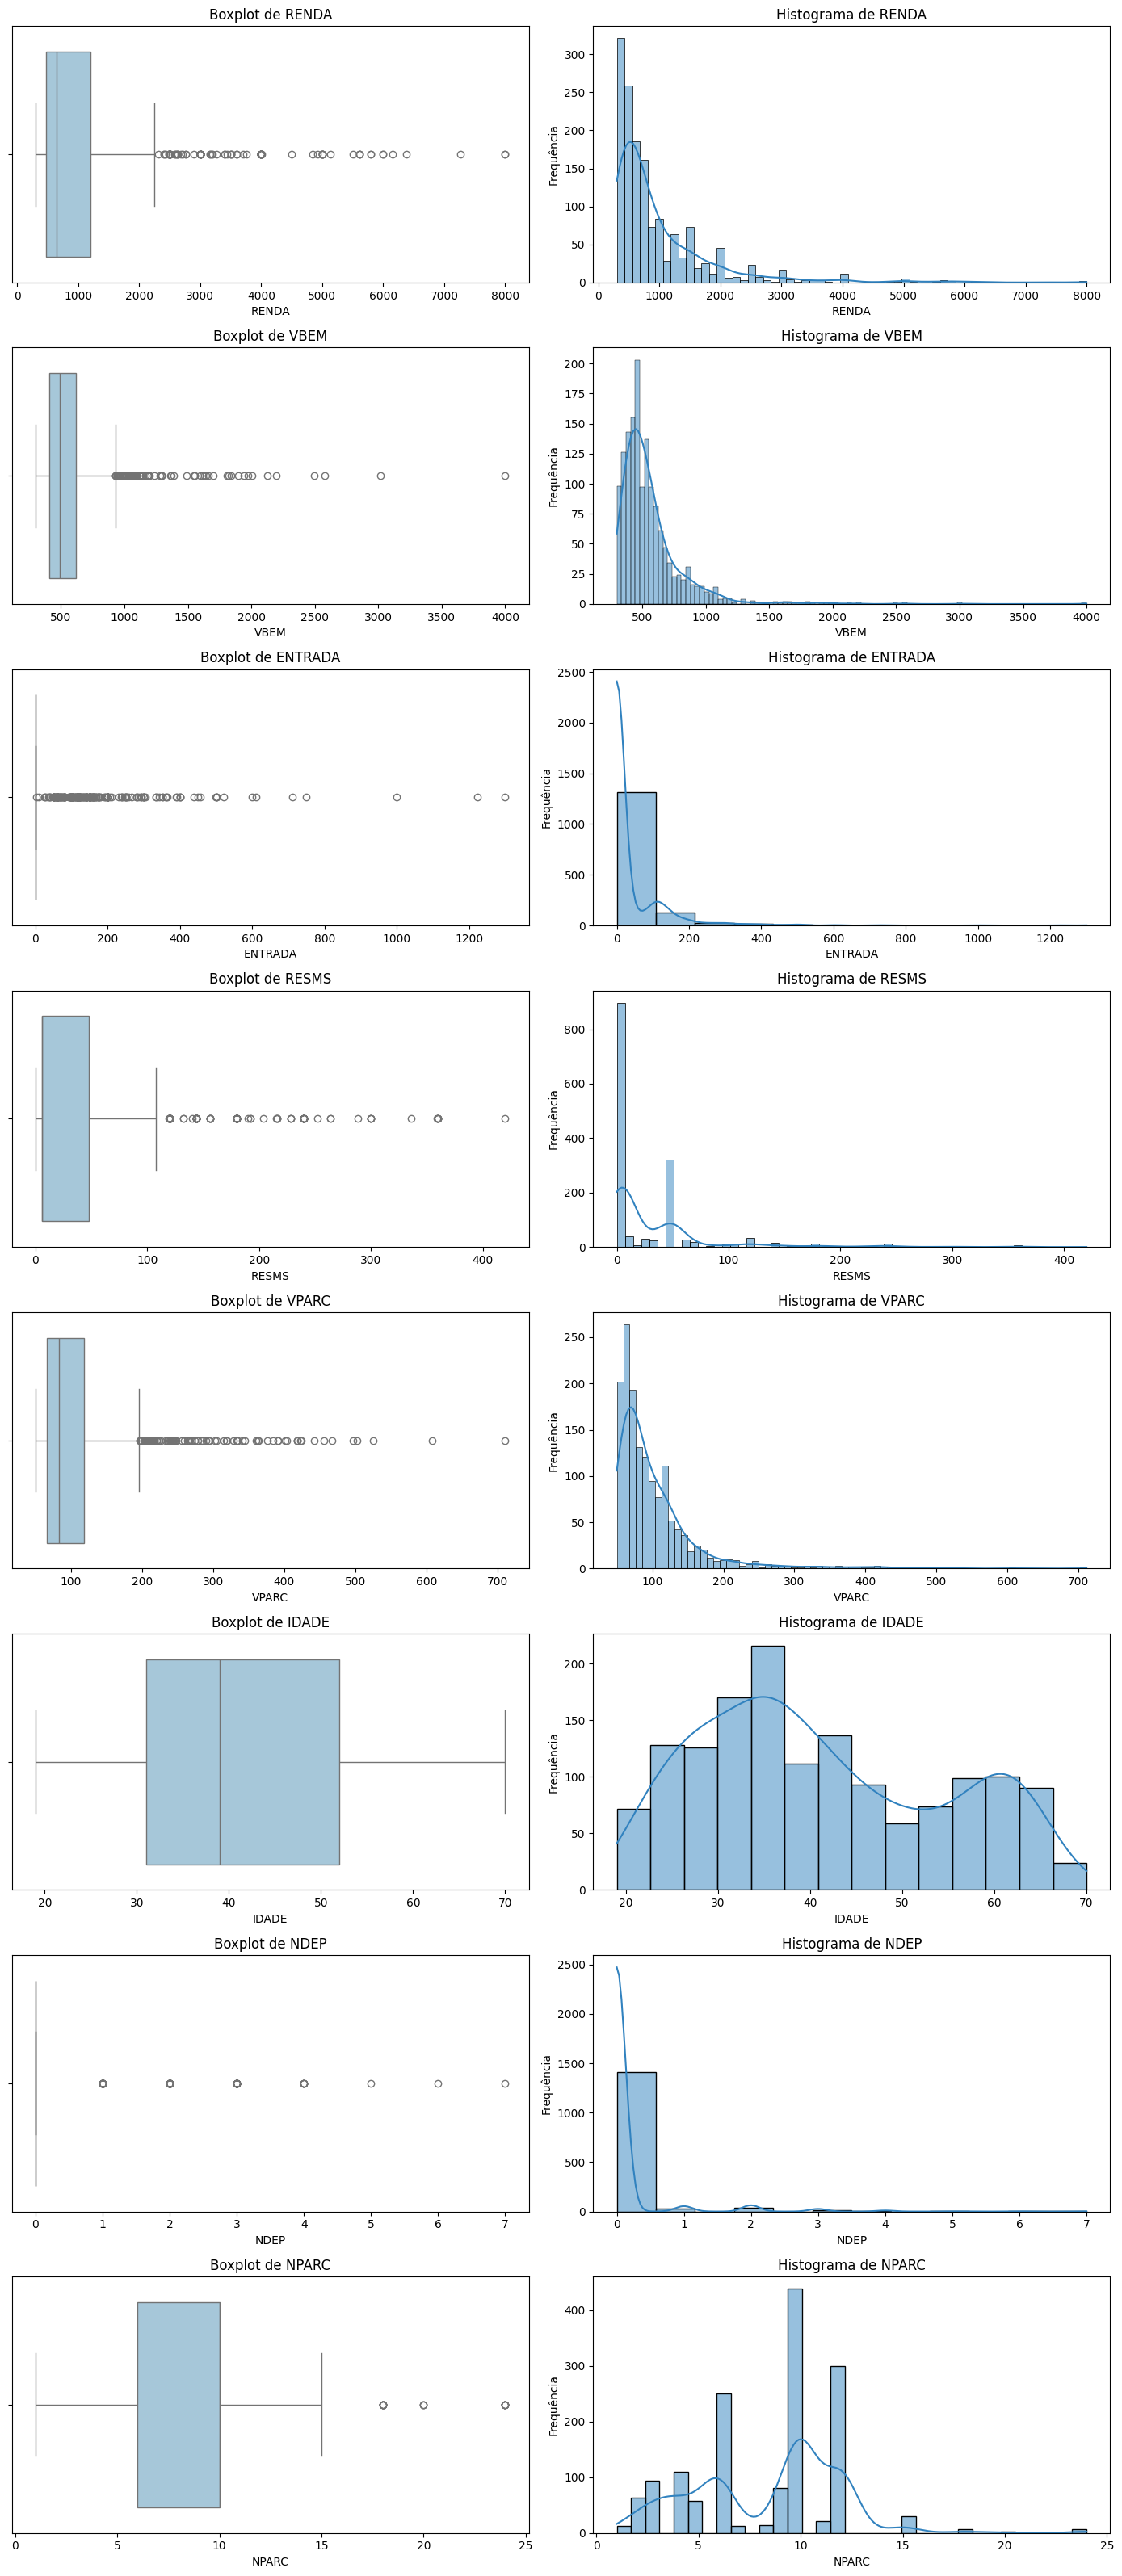

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

features_outliers = ["RENDA", "VBEM", "ENTRADA", "RESMS", "VPARC", "IDADE", "NDEP", "NPARC"]

fig, axes = plt.subplots(len(features_outliers), 2, figsize=(14, 4 * len(features_outliers)))

for i, col in enumerate(features_outliers):
    sns.boxplot(x=df_train[col], ax=axes[i, 0], color="#9ecae1")
    axes[i, 0].set_title(f"Boxplot de {col}")
    axes[i, 0].set_xlabel(col)

    sns.histplot(df_train[col], kde=True, ax=axes[i, 1], color="#3182bf")
    axes[i, 1].set_title(f"Histograma de {col}")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()


In [6]:
print(df_train["ESCT"].value_counts(), "\n")
print(df_train["TIPOR"].value_counts(), "\n")
print(df_train["TEL"].value_counts(), "\n")
print(df_train["CLASSE"].value_counts(), "\n")
print(df_train["NDEP"].value_counts().head(3), "\n")
print(df_train["ENTRADA"].value_counts().head(3), "\n")
print(df_train["RESMS"].value_counts().head(3), "\n")

print("Porcentagem de zeros na coluna NDEP:", (df_train['NDEP'] == 0).mean() * 100)
print("Porcentagem de zeros na coluna ENTRADA:", (df_train['ENTRADA'] == 0).mean() * 100)

ESCT
0    834
1    601
3     37
2     28
Name: count, dtype: int64 

TIPOR
0    832
1    668
Name: count, dtype: int64 

TEL
0    1299
1     201
Name: count, dtype: int64 

CLASSE
0    785
1    715
Name: count, dtype: int64 

NDEP
0    1409
2      36
1      31
Name: count, dtype: int64 

ENTRADA
0      1211
119      43
100      36
Name: count, dtype: int64 

RESMS
6     636
48    322
0     253
Name: count, dtype: int64 

Porcentagem de zeros na coluna NDEP: 93.93333333333334
Porcentagem de zeros na coluna ENTRADA: 80.73333333333333


 Feature alvo (CLASSE) não apresenta desbalanceamento. Temos que usar encoding na feature ESCT (Estado Civil). Como é uma feature de 4 clases, numérica e sem ordem, vou usar one hot encoding

In [7]:
df_train['tem_ENTRADA'] = (df_train['ENTRADA'] > 0).astype(int)
df_test['tem_ENTRADA']  = (df_test['ENTRADA'] > 0).astype(int)

df_train['tem_DEP'] = (df_train['NDEP'] > 0).astype(int)
df_test['tem_DEP']  = (df_test['NDEP'] > 0).astype(int)

df_train.drop(columns=['ENTRADA'], inplace=True)
df_test.drop(columns=['ENTRADA'], inplace=True)
df_train.drop(columns=['NDEP'], inplace=True)
df_test.drop(columns=['NDEP'], inplace=True)

print("tem_ENTRADA:\n", df_train['tem_ENTRADA'].value_counts())
print("\ntem_DEP:\n", df_train['tem_DEP'].value_counts())

print("\nColunas:", df_train.columns.tolist())

tem_ENTRADA:
 tem_ENTRADA
0    1211
1     289
Name: count, dtype: int64

tem_DEP:
 tem_DEP
0    1409
1      91
Name: count, dtype: int64

Colunas: ['ESCT', 'RENDA', 'TIPOR', 'VBEM', 'NPARC', 'VPARC', 'TEL', 'IDADE', 'RESMS', 'CLASSE', 'tem_ENTRADA', 'tem_DEP']


*Feature engineering*: Indicadores binários para variáveis com muitos zeros. Transformo (`NDEP`) e (`ENTRADA`) em features binárias, pois as variáveis apresentam fortes desbalanceamentos com predominâncias quase absolutas de zeros (94% e 80%), de modo que o sinal mais relevante passa a ser a presença ou ausência de dependentes. 

No caso de (`NDEP`) os valores positivos individuais são raros demais para fornecer padrões estáveis ao modelo (6%), então ultilizaremos somente a nova variável binária. 

Em (`ENTRADA`), além de criar uma feature binária (`tem_entrada`), tentei usar a feature original (`ENTRADA`) pois seus valores positivos (20%) não são dispensáveis. Porém, ao final de todos os treinos, fiz testes com e sem ela, e o resultado sem ela se mostrou melhor. Então novamente vamos optar só pela representação binária com (`tem_entrada`).



## Pré Processamento

In [8]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

target      = 'CLASSE'
skewed_cols = ['RENDA', 'VBEM', 'RESMS', 'VPARC']
other_num   = ['NPARC', 'IDADE']
binary_cols = ['TIPOR', 'TEL', 'tem_ENTRADA', 'tem_DEP']
cat_cols    = ['ESCT']

# Combinar treino e teste originais para redistribuir nas proporções 60/20/10/10
df_all = pd.concat([df_train, df_test], ignore_index=True)
X_all  = df_all.drop(columns=[target])
y_all  = df_all[target]

# 1º split: 80% temporário + 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# 2º split: do temporário, 75% treino (=60% total) + 25% para val+cal (=20% total)
X_train, X_temp2, y_train, y_temp2 = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# 3º split: 50/50 entre val e cal (cada um = 10% do total)
X_val, X_cal, y_val, y_cal = train_test_split(X_temp2, y_temp2, test_size=0.5, random_state=42)


# Pré-processamento para RL e KNN: log1p + StandardScaler + OHE
preprocessor = ColumnTransformer([
    ('log_scale', Pipeline([
        ('log',    FunctionTransformer(np.log1p)),
        ('scaler', StandardScaler()),
   ]),                                                         skewed_cols),
    ('scale', StandardScaler(),                                  other_num),
    ('ohe',   OneHotEncoder(drop='first', sparse_output=False),  cat_cols),
    ('pass',  'passthrough',                                     binary_cols),
])

# Pré-processamento para GradientBoosting: apenas OHE (sem escala, sem log1p)
preprocessor_tree = ColumnTransformer([
    ('ohe',  OneHotEncoder(drop='first', sparse_output=False), cat_cols),
    ('pass', 'passthrough', skewed_cols + other_num + binary_cols),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_cal_proc   = preprocessor.transform(X_cal)
X_test_proc  = preprocessor.transform(X_test)

# Para GradientBoosting, sem log1p e sem StandardScaler
X_train_proc_tree = preprocessor_tree.fit_transform(X_train)
X_val_proc_tree   = preprocessor_tree.transform(X_val)
X_cal_proc_tree   = preprocessor_tree.transform(X_cal)
X_test_proc_tree  = preprocessor_tree.transform(X_test)

total = len(X_all)
print(f"Total: {total} amostras")
print(f"Treino:     {X_train.shape[0]:4d}  ({X_train.shape[0]/total:.0%})")
print(f"Teste:      {X_test.shape[0]:4d}  ({X_test.shape[0]/total:.0%})")
print(f"Validação:  {X_val.shape[0]:4d}  ({X_val.shape[0]/total:.0%})")
print(f"Calibração: {X_cal.shape[0]:4d}  ({X_cal.shape[0]/total:.0%})")
print(f"\nTreino processado: {X_train_proc.shape}")

Total: 2077 amostras
Treino:     1245  (60%)
Teste:       416  (20%)
Validação:   208  (10%)
Calibração:  208  (10%)

Treino processado: (1245, 13)


In [9]:
X_train_proc[1]

array([ 1.53103517,  0.21658068,  0.93105111,  1.90215462, -1.50888401,
       -0.92213604,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

##  Treinamento dos Modelos

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

lr  = LogisticRegression()
knn = KNeighborsClassifier()
gb  = GradientBoostingClassifier()

lr.fit(X_train_proc,      y_train)
knn.fit(X_train_proc,     y_train)
gb.fit(X_train_proc_tree, y_train)

# dicionário: nome -> (modelo, X_val, X_cal, X_test) serve pra facilitar a avaliação e comparação dos modelos depois
models = {
    'Regressão Logística': (lr,  X_val_proc,      X_cal_proc,      X_test_proc),
    'KNN':                 (knn, X_val_proc,      X_cal_proc,      X_test_proc),
    'Gradient Boosting':   (gb,  X_val_proc_tree, X_cal_proc_tree, X_test_proc_tree),
}

print("Modelos treinados:", list(models.keys()))

Modelos treinados: ['Regressão Logística', 'KNN', 'Gradient Boosting']


##  Calibração dos Modelos 

Antes de escolher o limiar de classificação, calibramos as probabilidades dos modelos com Platt Scaling. Isso garante que o limiar escolhido seja interpretável — um limiar de 0.6 realmente representa ~60% de chance de inadimplência.

### Curva de Calibração — Modelos Base

A curva de calibração compara a probabilidade média predita pelo modelo com a fração real de positivos em cada bin. Um modelo perfeitamente calibrado segue a diagonal.

**Parâmetros usados:** `n_bins=5` (poucos dados no cal set — ~208 amostras) e `strategy='quantile'` (bins com igual número de amostras, evitando bins vazios que ocorrem com `strategy='uniform'`).

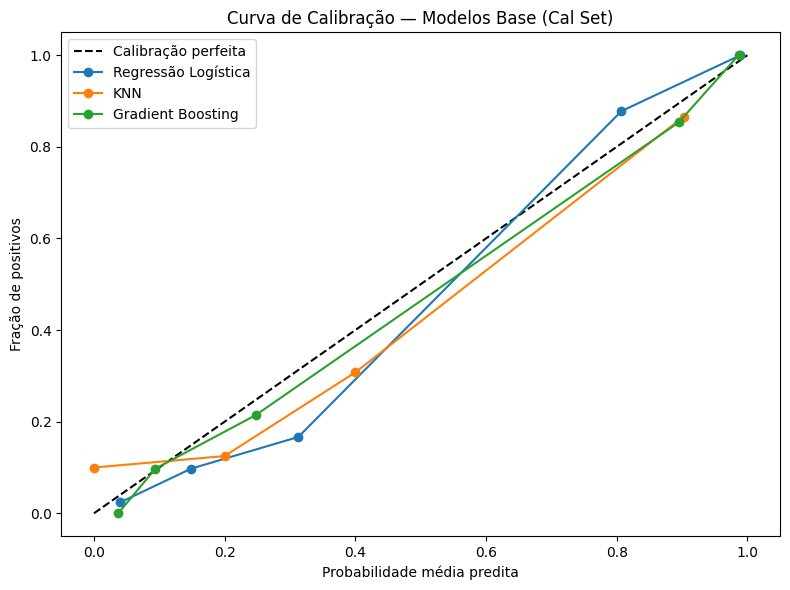

Modelo                     Brier Score     Log Loss
--------------------------------------------------
Regressão Logística             0.0756       0.2563
KNN                             0.1092       1.2823
Gradient Boosting               0.0732       0.2451


In [11]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Calibração perfeita')

for name, (model, Xval, Xcal, Xte) in models.items():
    y_prob_cal = model.predict_proba(Xcal)[:, 1]
    fop, mp = calibration_curve(y_cal, y_prob_cal, n_bins=5, strategy='quantile') # utilizar estratégia 'quantile' para garantir bins balanceados (como dataset pequeno, bins balanceados ajudam a ter pontos mais confiáveis na curva)
    ax.plot(mp, fop, marker='o', label=name)

ax.set_xlabel('Probabilidade média predita')
ax.set_ylabel('Fração de positivos')
ax.set_title('Curva de Calibração — Modelos Base (Cal Set)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Modelo':<25} {'Brier Score':>12} {'Log Loss':>12}")
print("-" * 50)
for name, (model, Xval, Xcal, Xte) in models.items():
    y_prob_cal = model.predict_proba(Xcal)[:, 1]
    print(f"{name:<25} {brier_score_loss(y_cal, y_prob_cal):>12.4f} {log_loss(y_cal, y_prob_cal):>12.4f}")

### Platt Scaling

Ajustamos uma Regressão Logística sobre os scores do cal set para transformar as probabilidades brutas em probabilidades bem calibradas. O modelo de calibração é ajustado no **cal set** (nunca no val ou test set) e verificado no **val set**.

Regressão Logística: Platt Scaling ajustado
KNN: Platt Scaling ajustado
Gradient Boosting: Platt Scaling ajustado


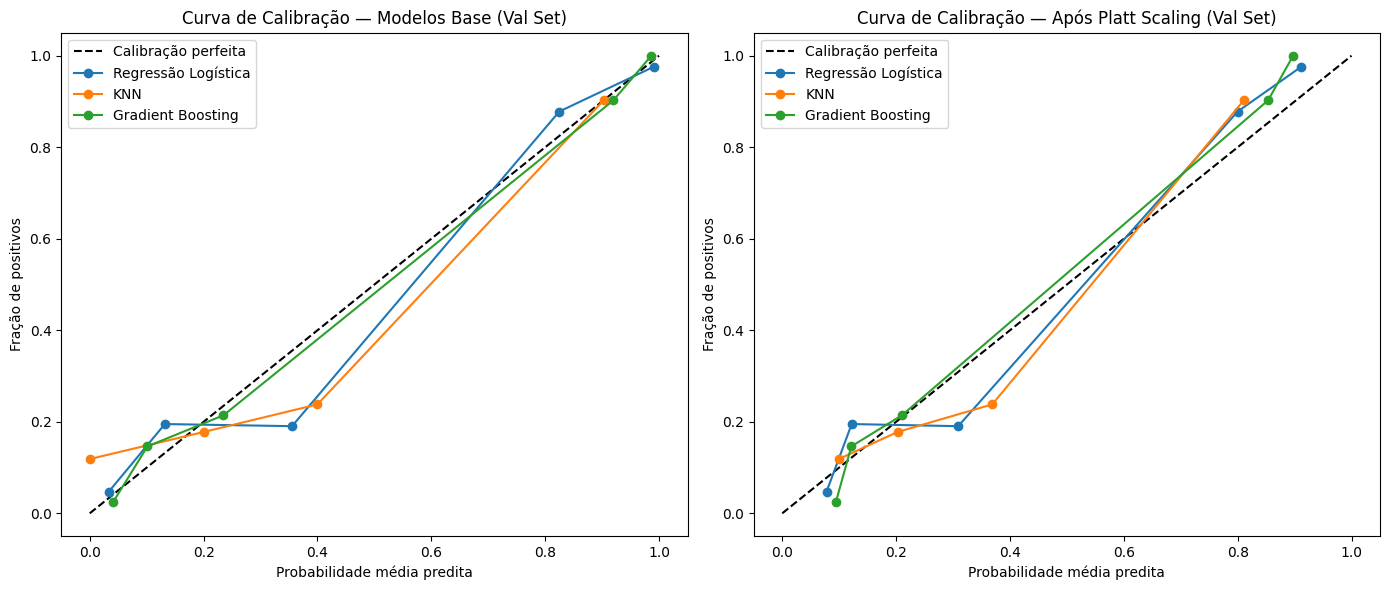


Modelo                     Brier Antes  Brier Depois  LogLoss Antes  LogLoss Depois
--------------------------------------------------------------------------------
Regressão Logística             0.0949        0.0933         0.3259          0.3272
KNN                             0.1190        0.1172         1.6324          0.3914
Gradient Boosting               0.0777        0.0807         0.2664          0.2939


In [12]:
from sklearn.linear_model import LogisticRegression as PlattLR
from sklearn.metrics import brier_score_loss, log_loss

platt_scalers = {}
for name, (model, Xval, Xcal, Xte) in models.items():
    scores_cal = model.predict_proba(Xcal)[:, 1].reshape(-1, 1)
    platt = PlattLR()
    platt.fit(scores_cal, y_cal)
    platt_scalers[name] = platt
    print(f"{name}: Platt Scaling ajustado")

# Curvas de calibração antes e depois no val set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, title in zip(axes, ['Modelos Base (Val Set)', 'Após Platt Scaling (Val Set)']):
    ax.plot([0, 1], [0, 1], 'k--', label='Calibração perfeita')
    ax.set_xlabel('Probabilidade média predita')
    ax.set_ylabel('Fração de positivos')
    ax.set_title(f'Curva de Calibração — {title}')

for name, (model, Xval, Xcal, Xte) in models.items():
    scores_val = model.predict_proba(Xval)[:, 1]
    fop_base, mp_base = calibration_curve(y_val, scores_val, n_bins=5, strategy='quantile')
    axes[0].plot(mp_base, fop_base, marker='o', label=name)

    y_prob_platt = platt_scalers[name].predict_proba(scores_val.reshape(-1, 1))[:, 1]
    fop_platt, mp_platt = calibration_curve(y_val, y_prob_platt, n_bins=5, strategy='quantile')
    axes[1].plot(mp_platt, fop_platt, marker='o', label=name)

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

# Brier Score e Log Loss antes e depois (val set)
print(f"\n{'Modelo':<25} {'Brier Antes':>12} {'Brier Depois':>13} {'LogLoss Antes':>14} {'LogLoss Depois':>15}")
print("-" * 80)
for name, (model, Xval, Xcal, Xte) in models.items():
    scores_val = model.predict_proba(Xval)[:, 1]
    y_prob_platt = platt_scalers[name].predict_proba(scores_val.reshape(-1, 1))[:, 1]
    brier_antes  = brier_score_loss(y_val, scores_val)
    brier_depois = brier_score_loss(y_val, y_prob_platt)
    ll_antes     = log_loss(y_val, scores_val)
    ll_depois    = log_loss(y_val, y_prob_platt)
    print(f"{name:<25} {brier_antes:>12.4f} {brier_depois:>13.4f} {ll_antes:>14.4f} {ll_depois:>15.4f}")

## Validação / Escolha do Limiar

Com as probabilidades calibradas, plotamos a curva ROC e escolhemos o limiar que minimiza o custo assimétrico (FP custa 10× mais que FN).

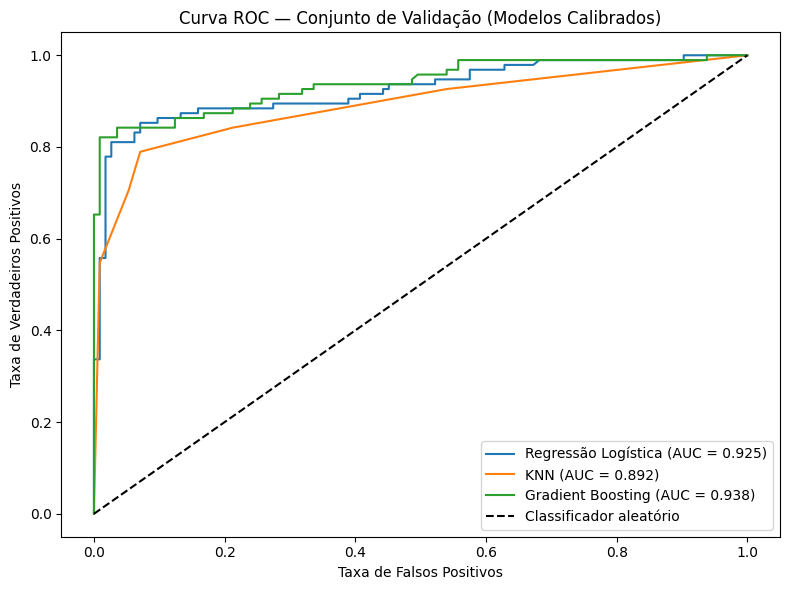

In [13]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

for name, (model, Xval, Xcal, Xte) in models.items():
    scores_val = model.predict_proba(Xval)[:, 1].reshape(-1, 1)
    y_prob = platt_scalers[name].predict_proba(scores_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Classificador aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Conjunto de Validação (Modelos Calibrados)')
ax.legend()
plt.tight_layout()
plt.show()

### Escolha do Limiar por Custo Assimétrico

Custo de falso positivo (FP) = 10× custo de falso negativo (FN). Minimizamos o custo esperado sobre os thresholds da curva ROC.

In [14]:
COST_FP = 10
COST_FN = 1

best_thresholds = {}
n_neg = (y_val == 0).sum()
n_pos = (y_val == 1).sum()

for name, (model, Xval, Xcal, Xte) in models.items():
    scores_val = model.predict_proba(Xval)[:, 1].reshape(-1, 1)
    y_prob = platt_scalers[name].predict_proba(scores_val)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)

    fp = fpr * n_neg
    fn = (1 - tpr) * n_pos
    custo = COST_FP * fp + COST_FN * fn

    idx = np.argmin(custo)
    best_thresholds[name] = thresholds[idx]

    print(f"{name}: limiar ótimo = {thresholds[idx]:.3f}  |  custo = {custo[idx]:.1f}  "
          f"(FP={fp[idx]:.0f}, FN={fn[idx]:.0f})")

Regressão Logística: limiar ótimo = 0.672  |  custo = 41.0  (FP=2, FN=21)
KNN: limiar ótimo = 0.877  |  custo = 53.0  (FP=1, FN=43)
Gradient Boosting: limiar ótimo = 0.797  |  custo = 27.0  (FP=1, FN=17)


##  Testes

  Regressão Logística  (limiar = 0.672)


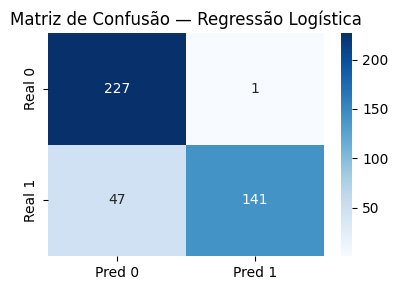

              precision    recall  f1-score   support

           0       0.83      1.00      0.90       228
           1       0.99      0.75      0.85       188

    accuracy                           0.88       416
   macro avg       0.91      0.87      0.88       416
weighted avg       0.90      0.88      0.88       416

AUC: 0.890

  KNN  (limiar = 0.877)


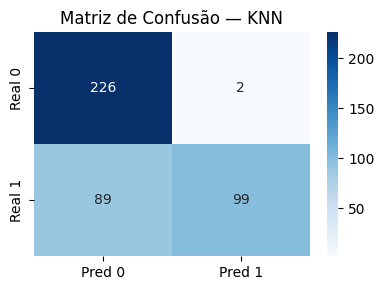

              precision    recall  f1-score   support

           0       0.72      0.99      0.83       228
           1       0.98      0.53      0.69       188

    accuracy                           0.78       416
   macro avg       0.85      0.76      0.76       416
weighted avg       0.84      0.78      0.77       416

AUC: 0.844

  Gradient Boosting  (limiar = 0.797)


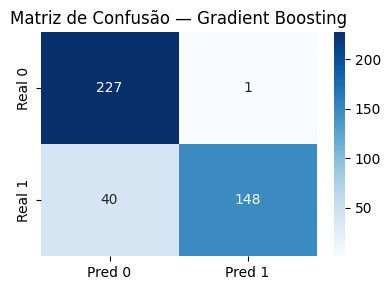

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       228
           1       0.99      0.79      0.88       188

    accuracy                           0.90       416
   macro avg       0.92      0.89      0.90       416
weighted avg       0.91      0.90      0.90       416

AUC: 0.927



In [15]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

for name, (model, Xval, Xcal, Xte) in models.items():
    thr = best_thresholds[name]
    scores_te = model.predict_proba(Xte)[:, 1].reshape(-1, 1)
    y_prob_te = platt_scalers[name].predict_proba(scores_te)[:, 1]
    y_pred_te = (y_prob_te >= thr).astype(int)

    print(f"{'='*50}")
    print(f"  {name}  (limiar = {thr:.3f})")
    print(f"{'='*50}")

    cm = confusion_matrix(y_test, y_pred_te)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Real 0', 'Real 1'])
    ax.set_title(f'Matriz de Confusão — {name}')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, y_pred_te))
    print(f"AUC: {roc_auc_score(y_test, y_prob_te):.3f}\n")